# SFML Project
## Comparing Machine Learning Algorithms for Classification and Regression

**Group members:**  
- MARYAM LACHHAB —  Master of Applied Informatics: Artificial intelligence and Data Science
- EMMA CROISEZ — Master of Physics: Research focus 
- DENIS YUSUFOV — Master of Physics: Research Focus

## 1. Introduction

in this project we ...

## 2. Research Questions

The project is organized around the following research questions:

1. How does noise affect classification performance?
2. 
3. What is the impact of class imbalance on the performance?

These questions are relevant because they help us understand both the predictive power and the limitations of machine learning models under different conditions.

# imports #####################################

In [91]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs, make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeRegressor

## 3. Datasets

We use two types of datasets in this project:

- A **synthetic dataset**, which allows us to control properties such as overlap and noise.
- A **real-world dataset**, which allows us to test the algorithms in a more realistic setting.



# Research Question 1

### How does noise affect classification performance?

This question is motivated by prior experience with X-ray image data, where model performance was negatively affected by noise and limited data.

To keep the analysis simple and interpretable, we do not use image data or convolutional neural networks. Instead, we use a synthetic dataset, which allows us to control the level of noise and clearly visualize its impact on classification performance.


In [92]:

# synthetic datatset 
##################1️⃣RESEARCH Q11️⃣##########################
from sklearn.datasets import make_blobs

X, y = make_blobs(
    n_samples=500,#500 examples 
    centers=2,#2 classes (broken , not broken bones)
    cluster_std=5.0,#noise (1 low noise , 5 high noise )
    random_state=42#
)

In [93]:
#real world datatset

# explain the dataset 

## 4. Data Preprocessing

Before training the models, we split the datasets into training and test sets. For some algorithms, we also standardize the features because they are sensitive to scale.

In [94]:
##################1️⃣RESEARCH Q11️⃣##########################
# Split the dataset into training and testing data
# 80% of the data will be used to train the models
# 20% will be used to test how well the models perform on unseen data

X_train, X_test, y_train, y_test = train_test_split(
    X,                  # Feature values (input data)
    y,                  # Class labels (target values)
    test_size=0.2,      # 20% of the data goes to the test set
    random_state=42     # Ensures reproducible results
)

# Create a StandardScaler object
# Standardization rescales the features so they have:
# mean = 0 and standard deviation = 1

scaler = StandardScaler()

# Fit the scaler on the training data and transform it
# The scaler learns the statistics from the training set only

X_train_scaled = scaler.fit_transform(X_train)

# Apply the same scaling to the test data


X_test_scaled = scaler.transform(X_test)

## 5. Machine Learning Models

For the classification task, we use:
- 
- 

For the regression task, we use:
- 
- 

These models were chosen because ...

In [106]:
##################1️⃣RESEARCH Q11️⃣##########################
# Create the Logistic Regression model

log_reg = LogisticRegression()

# Train the model using the training data

log_reg.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [97]:
##################1️⃣RESEARCH Q11️⃣##########################
# Create the Support Vector Machine model

svm_model = SVC()

# Train the SVM model

svm_model.fit(X_train_scaled, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [98]:
##################1️⃣RESEARCH Q11️⃣##########################
# Predict class labels using Logistic Regression

log_reg_predictions = log_reg.predict(X_test_scaled)

# Predict class labels using SVM

svm_predictions = svm_model.predict(X_test_scaled)

In [99]:
##################1️⃣RESEARCH Q11️⃣##########################
# Calculate Logistic Regression accuracy

log_reg_accuracy = accuracy_score(
    y_test,
    log_reg_predictions
)

# Calculate SVM accuracy

svm_accuracy = accuracy_score(
    y_test,
    svm_predictions
)

# Print results

print("Logistic Regression Accuracy:", log_reg_accuracy)
print("SVM Accuracy:", svm_accuracy)

Logistic Regression Accuracy: 0.9
SVM Accuracy: 0.92


# interpretation 

# visualization

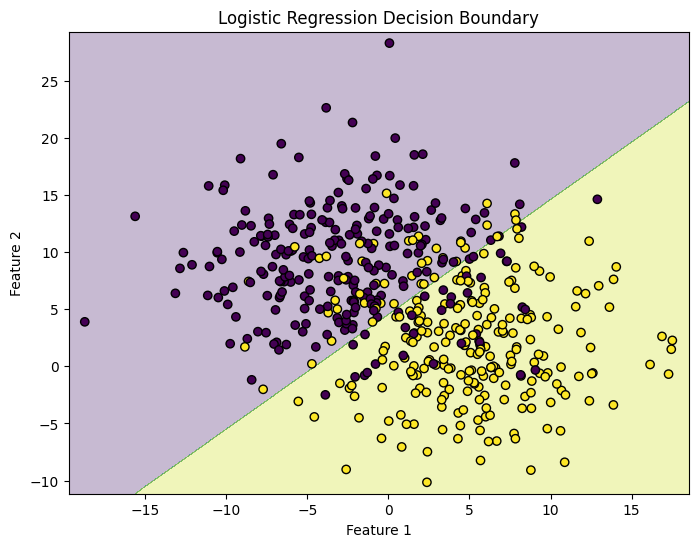

In [100]:
##################1️⃣RESEARCH Q11️⃣##########################
# Create a mesh grid for plotting

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

# Predict values across the grid

Z = log_reg.predict(
    scaler.transform(
        np.c_[xx.ravel(), yy.ravel()]
    )
)

# Reshape predictions to match grid

Z = Z.reshape(xx.shape)

# Plot decision boundary

plt.figure(figsize=(8,6))

plt.contourf(xx, yy, Z, alpha=0.3)

# Plot original data points

plt.scatter(
    X[:,0],
    X[:,1],
    c=y,
    edgecolors='k'
)

plt.title("Logistic Regression Decision Boundary")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()

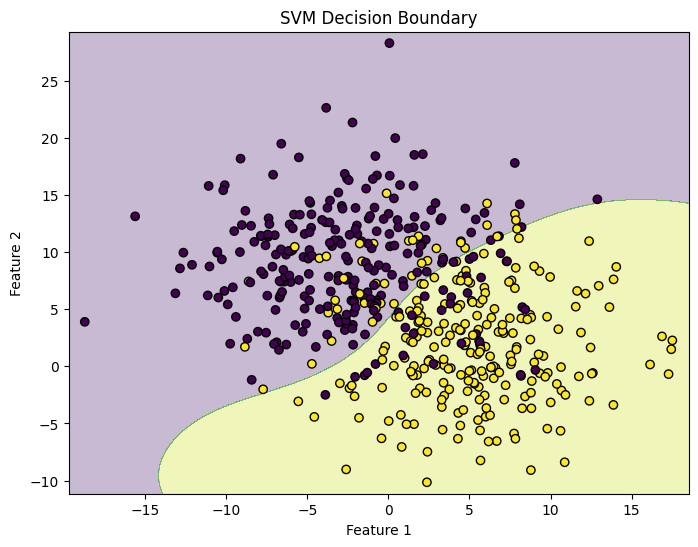

In [101]:
##################1️⃣RESEARCH Q11️⃣##########################
# Predict values across the grid

Z = svm_model.predict(
    scaler.transform(
        np.c_[xx.ravel(), yy.ravel()]
    )
)

# Reshape predictions

Z = Z.reshape(xx.shape)

# Plot decision boundary

plt.figure(figsize=(8,6))

plt.contourf(xx, yy, Z, alpha=0.3)

# Plot data points

plt.scatter(
    X[:,0],
    X[:,1],
    c=y,
    edgecolors='k'
)

plt.title("SVM Decision Boundary")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()

# Research question 2 : In the case of SVM, what is the impact of class overlap, class unbalance and mislabeled data on the number and location of support vectors?

In [102]:
# code for training the models etc

## Interpretation 

# visualization 

In [103]:
# code for visualization 

# Research question 3 (Denis)

### What is the impact of class imbalance on the performance? 

The research question is motivated in the context of binary classfication between signal and background, in which case background is over-dominating the signal. 

For instance, Gamma-ray Cherenkov telescopes data can be classified between the following two classes: gamma-rays (signal) and cosmic ray induced hadronic showers (background). 

Real data from the MAGIC gamma telescope is available on Kaggle. The idea is to use such dataset to potentially compare the performance between imbalanced classes and a balanced version (or something in those lines).


Denis



In [104]:
# code for training the models etc 
df = pd.read_csv('telescope_data.csv')

print(f'Dataset Shape : {df.shape}')
print(f'Target Classes: {df["class"].unique()}')

Dataset Shape : (19020, 12)
Target Classes: ['g' 'h']


# interpretation 

# visualization

In [105]:
# code for visualization 

# Results and discussion

# Conclusion